#### Advanced Mutual Fund Analytics
Tasks Covered:
- Historical VaR & CVaR
- Rolling 90-Day Sharpe Ratio

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

plt.style.use("ggplot")


In [2]:
DATA = Path("../data/processed")

nav = pd.read_csv(
    DATA / "nav_history_clean.csv",
    parse_dates=["date"]
)

fund = pd.read_csv(
    DATA / "fund_master_clean.csv"
)

performance = pd.read_csv(
    DATA / "scheme_performance_clean.csv"
)

print(nav.head())


   amfi_code       date       nav
0     100016 2022-01-03  520.4608
1     100016 2022-01-04  515.0971
2     100016 2022-01-05  521.7239
3     100016 2022-01-06  515.7880
4     100016 2022-01-07  515.1639


In [3]:
# calcualte daily returns

nav = nav.sort_values(
    ["amfi_code", "date"]
)
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head()


,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [4]:
var_report = []

for code in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == code
    ]["daily_return"].dropna()

    if len(temp) == 0:
        continue

    # Historical VaR (95%)

    var95 = np.percentile(temp,5)

    # CVaR

    cvar95 = temp[temp <= var95].mean()

    var_report.append({

        "amfi_code":code,
        "VaR_95":var95,
        "CVaR_95":cvar95

    })

var_df = pd.DataFrame(var_report)


In [5]:
# merge fund names
var_df = var_df.merge(

    fund[
        ["amfi_code","scheme_name"]
    ],

    on="amfi_code",
    how="left"

)

var_df.head()


,amfi_code,VaR_95,CVaR_95,scheme_name
0,100016,-0.014364,-0.018060,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.003793,-0.004994,HDFC Short Term Debt Fund - Regular - Growth
2,100033,-0.019034,-0.023456,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,-0.013282,-0.017439,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-0.026021,-0.032459,ABSL Small Cap Fund - Regular - Growth


In [6]:
# sort worst funds 
var_df = var_df.sort_values(

    "VaR_95"

)

var_df.head(10)


,amfi_code,VaR_95,CVaR_95,scheme_name
22,119599,-0.026859,-0.032384,SBI Small Cap Fund - Direct Plan - Growth
17,119095,-0.026188,-0.031667,Axis Small Cap Fund - Regular - Growth
4,101207,-0.026021,-0.032459,ABSL Small Cap Fund - Regular - Growth
11,118634,-0.025438,-0.032304,Nippon India Small Cap Fund - Regular - Growth
21,119598,-0.024507,-0.030595,SBI Small Cap Fund - Regular Plan - Growth
39,149324,-0.023483,-0.031036,DSP Small Cap Fund - Regular - Growth
7,102886,-0.019220,-0.023251,UTI Mid Cap Fund - Regular - Growth
2,100033,-0.019034,-0.023456,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
25,120505,-0.018892,-0.024342,ICICI Pru Midcap Fund - Regular - Growth
16,119094,-0.018480,-0.024260,Axis Midcap Fund - Regular - Growth


In [ ]:
# export to csv
var_df.to_csv(

    "../reports/var_cvar_report.csv",

    index=False

)

print("CSV Exported Successfully")


#### Historical VaR & CVaR
VaR (95%) represents the expected worst daily loss with 95% confidence.
CVaR measures the average loss beyond the VaR threshold.

#### Rolling 90-Day Sharpe Ratio

In [8]:
# choose 5 key funds
key_funds = [

119551,
120503,
118632,
119092,
120841

]


In [ ]:
risk_free = 0.065
daily_rf = risk_free/252


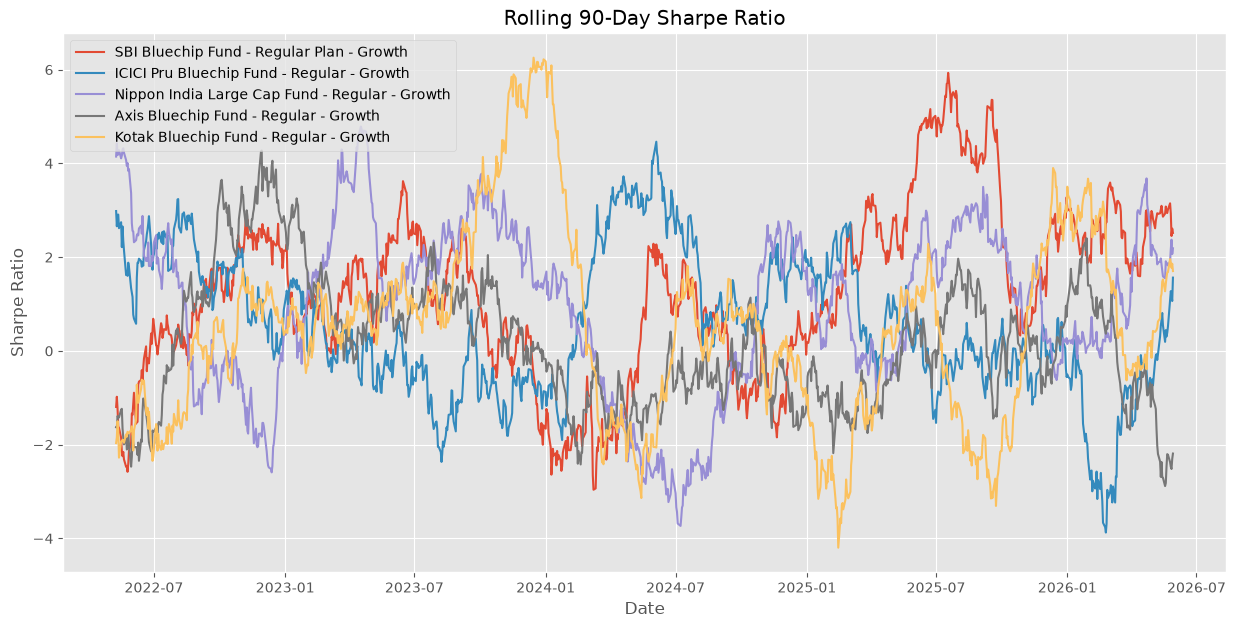

In [10]:
# rolling sharp ratio

plt.figure(figsize=(15,7))

for code in key_funds:

    temp = nav[
        nav["amfi_code"]==code
    ].copy()

    temp["rolling_sharpe"] = (

        (
            temp["daily_return"]-daily_rf
        )

        .rolling(90)
        .mean()

        /

        temp["daily_return"]

        .rolling(90)

        .std()

    )*np.sqrt(252)

    name = fund.loc[

        fund["amfi_code"]==code,

        "scheme_name"

    ].values[0]

    plt.plot(

        temp["date"],

        temp["rolling_sharpe"],

        label=name

    )

plt.title(

    "Rolling 90-Day Sharpe Ratio"

)

plt.xlabel("Date")

plt.ylabel("Sharpe Ratio")

plt.legend()

plt.grid(True)


In [11]:
# save the figure
plt.savefig(

    "../reports/charts/rolling_sharpe_chart.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()


<Figure size 640x480 with 0 Axes>

#### Rolling Sharpe Ratio
The Rolling 90-Day Sharpe Ratio shows how risk-adjusted performance changes over time.
Higher values indicate better returns for the level of risk taken.

#### Investor Cohort Analysis
This analysis groups investors based on their first transaction year and calculates:
- Average SIP Amount
- Total Amount Invested
- Most Preferred Fund


In [12]:
txn = pd.read_csv(
    "../data/processed/investor_transactions_clean.csv",
    parse_dates=["transaction_date"]
)

txn.head()


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,VERIFIED
1,INV002952,2024-01-01,148567,REDEMPTION,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,VERIFIED
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,VERIFIED
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,PENDING
4,INV004691,2024-01-01,119094,LUMPSUM,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,PENDING


In [13]:
# First transaction date for every investor
first_txn = (
    txn.groupby("investor_id")["transaction_date"]
       .min()
       .reset_index()
)

first_txn["cohort_year"] = first_txn["transaction_date"].dt.year

first_txn.head()


,investor_id,transaction_date,cohort_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024


In [14]:
# merge chorot year
txn = txn.merge(
    first_txn[
        ["investor_id", "cohort_year"]
    ],
    on="investor_id",
    how="left"
)

txn.head()


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,VERIFIED,2024
1,INV002952,2024-01-01,148567,REDEMPTION,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,VERIFIED,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,VERIFIED,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,PENDING,2024
4,INV004691,2024-01-01,119094,LUMPSUM,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,PENDING,2024


In [15]:
# avg SIP amount by cohort year
sip_avg = (
    txn[
        txn["transaction_type"] == "SIP"
    ]
    .groupby("cohort_year")["amount_inr"]
    .mean()
    .round(2)
    .reset_index(name="avg_sip_amount")
)

sip_avg


,cohort_year,avg_sip_amount
0,2024,10996.89
1,2025,13505.21


In [17]:
# total invasted amount 
total_inv = (
    txn.groupby("cohort_year")["amount_inr"]
       .sum()
       .reset_index(name="total_invested")
)

total_inv


,cohort_year,total_invested
0,2024,3491125187
1,2025,30455243


In [18]:
# top prefrence of funds

top_fund = (
    txn.groupby(
        ["cohort_year", "amfi_code"]
    )
    .size()
    .reset_index(name="count")
)

top_fund = (
    top_fund.sort_values(
        ["cohort_year", "count"],
        ascending=[True, False]
    )
    .drop_duplicates("cohort_year")
)

top_fund = top_fund.merge(
    fund[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

top_fund = top_fund[
    ["cohort_year", "scheme_name"]
]

top_fund


,cohort_year,scheme_name
0,2024,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,SBI Small Cap Fund - Direct Plan - Growth


In [ ]:
# final cohort table 

cohort = (
    sip_avg.merge(
        total_inv,
        on="cohort_year"
    )
    .merge(
        top_fund,
        on="cohort_year"
    )
)

cohort


,cohort_year,avg_sip_amount,total_invested,scheme_name
0,2024,10996.89,3491125187,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,13505.21,30455243,SBI Small Cap Fund - Direct Plan - Growth


##### Insight
Recent investor cohorts have increased their average SIP contribution, while popular equity funds continue attracting the highest investments.


#### SIP Continuity Analysis
Identify investors having six or more SIP transactions and calculate the average gap between consecutive SIPs.
Investors with an average gap greater than 35 days are marked as **At Risk**.


In [21]:
#  filter sip transactions 
sip = txn[
    txn["transaction_type"] == "SIP"
].copy()

sip = sip.sort_values(
    ["investor_id", "transaction_date"]
)

sip.head()


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,VERIFIED,2024
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,PENDING,2024
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,VERIFIED,2024
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,VERIFIED,2024
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,VERIFIED,2024


In [22]:
# calculate gap 

sip["gap_days"] = (
    sip.groupby("investor_id")["transaction_date"]
       .diff()
       .dt.days
)

sip.head()


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,gap_days
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,VERIFIED,2024,NaN
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,PENDING,2024,76.0
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,VERIFIED,2024,NaN
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,VERIFIED,2024,176.0
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,VERIFIED,2024,238.0


In [23]:
# keep investors with 6 SIPs
counts = (
    sip.groupby("investor_id")
       .size()
)

eligible = counts[
    counts >= 6
].index

sip = sip[
    sip["investor_id"].isin(eligible)
]


In [24]:
# avg gap 
continuity = (
    sip.groupby("investor_id")
       .agg(
           avg_gap_days=("gap_days", "mean"),
           sip_count=("transaction_date", "count")
       )
       .reset_index()
)

continuity.head()


,investor_id,avg_gap_days,sip_count
0,INV000004,85.400000,6
1,INV000008,70.400000,6
2,INV000010,64.800000,6
3,INV000011,40.166667,7
4,INV000012,57.000000,8


In [25]:
# flag At-risk investors
continuity["status"] = np.where(

    continuity["avg_gap_days"] > 35,

    "At Risk",

    "Active"

)

continuity.head()


,investor_id,avg_gap_days,sip_count,status
0,INV000004,85.400000,6,At Risk
1,INV000008,70.400000,6,At Risk
2,INV000010,64.800000,6,At Risk
3,INV000011,40.166667,7,At Risk
4,INV000012,57.000000,8,At Risk


In [26]:
# summerry
continuity["status"].value_counts()


status
At Risk    1332
Active       30
Name: count, dtype: int64

In [27]:
# display At-risk investors
continuity[
    continuity["status"] == "At Risk"
].head(10)


,investor_id,avg_gap_days,sip_count,status
0,INV000004,85.400000,6,At Risk
1,INV000008,70.400000,6,At Risk
2,INV000010,64.800000,6,At Risk
3,INV000011,40.166667,7,At Risk
4,INV000012,57.000000,8,At Risk
5,INV000013,55.333333,7,At Risk
6,INV000014,75.333333,7,At Risk
7,INV000023,58.571429,8,At Risk
8,INV000028,93.600000,6,At Risk
9,INV000029,60.666667,7,At Risk


##### Insight

Most investors maintain regular monthly SIPs, while a small group shows gaps of more than 35 days and may require follow-up to improve investment continuity.

#### Recommender -> recommender.py

#### Sector Concentration (HHI)
HHI measures portfolio concentration.
Higher HHI = More concentrated portfolio.
Lower HHI = Better diversified.


In [ ]:
portfolio = pd.read_csv(
    "../data/processed/portfolio_holdings_clean.csv"
)

portfolio.head()


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


#### HHI = Σ(weight²) [formula]

In [29]:
hhi = (
    portfolio.groupby("amfi_code")
    .apply(
        lambda x:
        (x["weight_pct"]/100)
        .pow(2)
        .sum()
    )
    .reset_index(name="HHI")
)

hhi.head()


,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [ ]:
# fund names 
hhi = hhi.merge(
    fund[
        ["amfi_code","scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

hhi.head()


,amfi_code,HHI,scheme_name
0,100016,0.139534,HDFC Top 100 Fund - Regular Plan - Growth
1,100033,0.147592,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
2,101206,0.129332,ABSL Frontline Equity Fund - Regular - Growth
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth


In [31]:
# most concentrated funds
hhi.sort_values(
    "HHI",
    ascending=False
).head(10)


,amfi_code,HHI,scheme_name
11,119092,0.206448,Axis Bluechip Fund - Regular - Growth
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth
18,119599,0.174751,SBI Small Cap Fund - Direct Plan - Growth
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth
7,118632,0.168298,Nippon India Large Cap Fund - Regular - Growth
29,148568,0.167930,Mirae Asset Emerging Bluechip Fund - Regular -...
21,120505,0.157570,ICICI Pru Midcap Fund - Regular - Growth
22,120506,0.153794,ICICI Pru Value Discovery Fund - Regular - Growth
27,125498,0.152414,HDFC Mid-Cap Opportunities Fund - Direct - Growth
23,120841,0.149680,Kotak Bluechip Fund - Regular - Growth


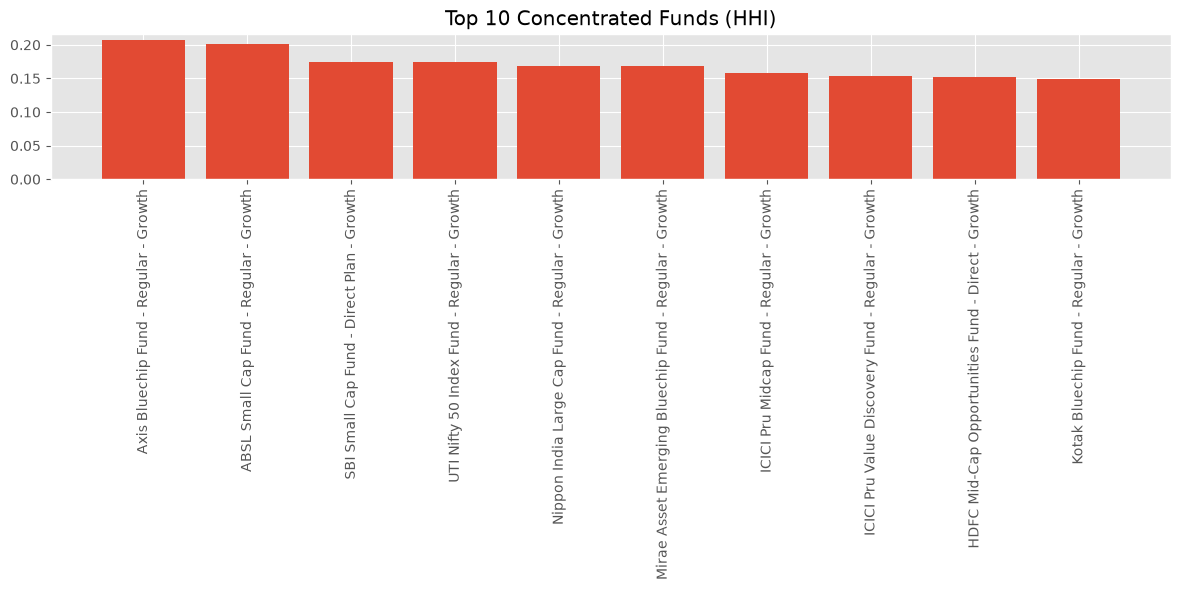

In [32]:
# HHI chart
top_hhi = (
    hhi.sort_values(
        "HHI",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12,6))

plt.bar(
    top_hhi["scheme_name"],
    top_hhi["HHI"]
)

plt.xticks(
    rotation=90
)

plt.title(
    "Top 10 Concentrated Funds (HHI)"
)

plt.tight_layout()

plt.show()


### key insights

-> Funds with the lowest VaR values experienced the highest downside risk and were more sensitive during market corrections.

-> Recent investor cohorts contributed a larger total investment amount compared to older cohorts, indicating growing retail participation.

-> A small percentage of investors showed SIP gaps greater than 35 days and were classified as at-risk investors.

-> Funds with higher Sharpe ratios consistently delivered better risk-adjusted returns than their peers.

-> Highly concentrated portfolios recorded larger HHI values, suggesting greater dependence on a limited number of sectors.